# Dummy simulation
---

In [1]:
from dual_spls.simulate import simulate
import numpy as np

In [2]:
## Configuration:
# Simulation configuration:
coefs = [0, 1, 0, 1, 1, 0, 0, 1, 1] 
n = 300
p = [1000]
nondes = [30]
sigmaondes = [0.40]
sigma_y = 0.05

# Split configuration:
split_mode = "calvalxy"

# Dual-sPLS configuration
norm = "pseudo-lasso" # options: "pseudo-lasso", ...

In [3]:
# generate synthetic data
simulation_results = simulate(n=n, p=p, nondes=nondes , sigmaondes=sigmaondes, sigma_y=sigma_y, coefs=coefs)
X, y = simulation_results["X"], simulation_results["y"]

In [4]:
# split data
if split_mode == "random":
    # split data randomly
    from sklearn.model_selection import train_test_split

    print("Splitting data using a classic random split.")
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
if split_mode == "calvalxy":
    # split data using the paper's calvalxy method
    from dual_spls.calvalxy import calvalXY

    splits = calvalXY(X, y, method="pca_euclidian")
    cal_ind, val_ind = splits["indcal"], splits["indval"]

    X_train, y_train = X[cal_ind], y[cal_ind]
    X_test, y_test = X[val_ind], y[val_ind]

[INFO] pcal not specified. Using default value 90%
[INFO] Centered data


In [5]:
X

array([[7.2852577 , 7.29917126, 7.31308165, ..., 8.63246334, 8.61796622,
        8.60345453],
       [9.00671825, 9.02331951, 9.03990955, ..., 7.53851154, 7.52259318,
        7.50667695],
       [8.04609181, 8.06171087, 8.07732437, ..., 7.95931625, 7.94387635,
        7.92843209],
       ...,
       [7.54312394, 7.55727738, 7.57142442, ..., 7.44148463, 7.4271169 ,
        7.41274381],
       [8.13861825, 8.15442285, 8.17022017, ..., 7.24038285, 7.22513459,
        7.20988755],
       [7.88845843, 7.9035167 , 7.91856818, ..., 7.13192359, 7.11710955,
        7.10229556]])

In [6]:
y

array([5963.80209429, 6334.45693347, 6140.17339688, 5825.6019983 ,
       4867.45310554, 5065.5353361 , 6147.8454591 , 5101.42581678,
       6020.55344459, 5788.07609788, 6608.70084949, 6033.16446791,
       5639.8856238 , 5126.65784806, 5480.58683847, 4963.86212034,
       5047.23525418, 5487.52887389, 5677.93382563, 5395.44243974,
       4866.51108014, 5179.71411127, 5300.25138322, 4970.50362157,
       6210.91578365, 5773.64716619, 5518.1539701 , 4973.36734621,
       4945.80870803, 4714.68087767, 6029.89309076, 6041.69250493,
       5630.75936369, 5520.32609409, 4688.88068285, 6120.61035129,
       4599.03568796, 5802.3840729 , 6456.68384994, 5798.15902778,
       5991.06466367, 4856.76020912, 7003.32588031, 5899.24348802,
       5996.21638245, 5538.25958437, 5833.08868593, 5204.32227186,
       5849.37486838, 4623.47317857, 4029.83043327, 5728.36582637,
       4840.71096605, 5214.18650032, 5876.09891   , 5333.12172016,
       6177.15368458, 6425.77374676, 6802.59049354, 4997.62459

In [7]:
# standardize data (after splitting to avoid data leakage)
from sklearn.preprocessing import StandardScaler

X_scaler = StandardScaler()
X_train_scaled = X_scaler.fit_transform(X_train)
X_test_scaled = X_scaler.transform(X_test)       

y_scaler = StandardScaler()
y_train_scaled= y_scaler.fit_transform(y_train.reshape(-1, 1)).flatten()
y_test_scaled = y_scaler.transform(y_test.reshape(-1, 1)).flatten()


In [8]:
# apply Dual-sPLS
from dual_spls.lasso import dual_spls_lasso

results = {}
if norm == "pseudo-lasso":
    print("Applying Dual-sPLS with the \"pseudo-lasso\" norm.")

    for n_comp in range(1, 10):
        result = dual_spls_lasso(X_train_scaled, y_train_scaled, n_components=n_comp, ppnu=0.99)
        beta = result['Bhat'][:, -1]
        intercept = result['intercept'][-1]

        y_pred_scaled = (X_test_scaled @ beta + intercept).flatten()

        rmse = np.sqrt(np.mean((y_test_scaled - y_pred_scaled)**2))
        results[f"rmse_{n_comp}_comp"] = rmse

results

Applying Dual-sPLS with the "pseudo-lasso" norm.
Dual PLS Lasso ic=1 lambda1=13611.9773 mu=0.0198 nu=269.1113804130265 nbzeros=990
Dual PLS Lasso ic=1 lambda1=13611.9773 mu=0.0198 nu=269.1113804130265 nbzeros=990
Dual PLS Lasso ic=2 lambda1=20.9635 mu=0.2123 nu=4.4496237037310955 nbzeros=980
Dual PLS Lasso ic=1 lambda1=13611.9773 mu=0.0198 nu=269.1113804130265 nbzeros=990
Dual PLS Lasso ic=2 lambda1=20.9635 mu=0.2123 nu=4.4496237037310955 nbzeros=980
Dual PLS Lasso ic=3 lambda1=22.5590 mu=0.2989 nu=6.743949545289139 nbzeros=970
Dual PLS Lasso ic=1 lambda1=13611.9773 mu=0.0198 nu=269.1113804130265 nbzeros=990
Dual PLS Lasso ic=2 lambda1=20.9635 mu=0.2123 nu=4.4496237037310955 nbzeros=980
Dual PLS Lasso ic=3 lambda1=22.5590 mu=0.2989 nu=6.743949545289139 nbzeros=970
Dual PLS Lasso ic=4 lambda1=1037.4841 mu=0.0000 nu=0.026981721747692228 nbzeros=960
Dual PLS Lasso ic=1 lambda1=13611.9773 mu=0.0198 nu=269.1113804130265 nbzeros=990
Dual PLS Lasso ic=2 lambda1=20.9635 mu=0.2123 nu=4.44962370

{'rmse_1_comp': 0.07849199414438754,
 'rmse_2_comp': 0.07405524677434006,
 'rmse_3_comp': 0.003980384942745025,
 'rmse_4_comp': 0.000850190800754424,
 'rmse_5_comp': 8.410190416113251e-05,
 'rmse_6_comp': 7.781722204705277e-05,
 'rmse_7_comp': 7.710805888975186e-05,
 'rmse_8_comp': 7.712097649772573e-05,
 'rmse_9_comp': 7.851698040046125e-05}

In [9]:
# apply PLS
from sklearn.cross_decomposition import PLSRegression

results_PLS = {}
for n_comp in range(1, 10):
        PLS = PLSRegression(n_components=n_comp, scale=False, copy=True)
        PLS.fit(X_train_scaled, y_train_scaled)

        y_pred_scaled = PLS.predict(X_test_scaled).flatten()

        rmse = np.sqrt(np.mean((y_test_scaled - y_pred_scaled)**2))
        results_PLS[f"rmse_{n_comp}_comp"] = rmse

results_PLS

{'rmse_1_comp': 0.02771839414769626,
 'rmse_2_comp': 0.006036682022731636,
 'rmse_3_comp': 0.0029550984508326674,
 'rmse_4_comp': 9.051112081447179e-05,
 'rmse_5_comp': 7.913571416279675e-05,
 'rmse_6_comp': 7.727243499941552e-05,
 'rmse_7_comp': 7.711406388507034e-05,
 'rmse_8_comp': 7.712154445780232e-05,
 'rmse_9_comp': 7.809192463260473e-05}

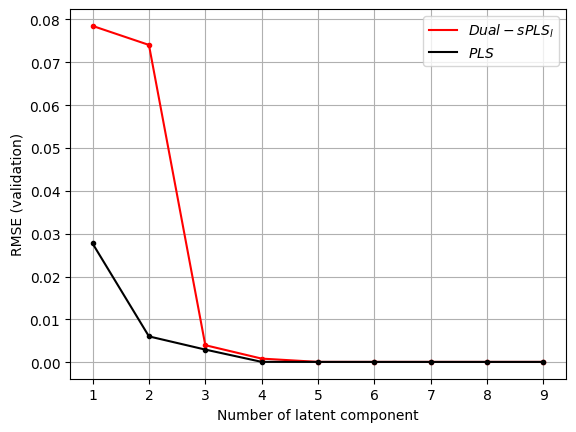

In [10]:
import matplotlib.pyplot as plt

plt.plot(range(1, 10), list(results.values()), color='red',label="$Dual-sPLS_l$")
plt.plot(range(1, 10), list(results.values()), ".", color='red')

plt.plot(range(1, 10), list(results_PLS.values()), color='black',label="$PLS$")
plt.plot(range(1, 10), list(results_PLS.values()), ".", color='black')

plt.xlabel("Number of latent component")
plt.ylabel("RMSE (validation)")
plt.grid()
plt.legend()
plt.show()